# Pruning 

# 1- Unstructured Pruning 

Unstructured pruning demo on MNIST (PyTorch)
- Train a tiny MLP for 1 epoch (baseline)
- Apply global unstructured pruning (e.g., 80% of weights in Linear layers)
- Measure sparsity + accuracy drop
- Fine-tune briefly to recover
- Make pruning permanent (prune.remove) 

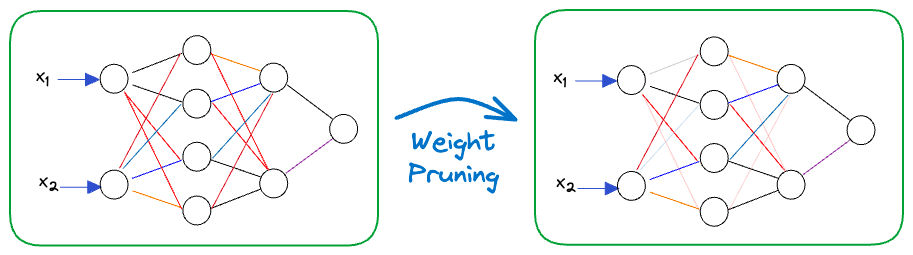


In [27]:
# for colab
# !pip install -U torch==2.6.0 torchvision==0.21.0 pandas==2.2.2 numpy==2.0.2 scipy==1.16.3 

In [28]:
# Unstructured pruning demo on MNIST (PyTorch)
# - Train a tiny MLP for 1 epoch (baseline)
# - Apply global unstructured pruning (e.g., 80% of weights in Linear layers)
# - Measure sparsity + accuracy drop
# - Fine-tune briefly to recover
# - Make pruning permanent (prune.remove)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.nn.utils import prune
import random

# ----------------------------
# Repro + device
# ----------------------------
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [29]:
# ----------------------------
# Data (MNIST)
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True if device.type=="cuda" else False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True if device.type=="cuda" else False)


In [30]:

# ----------------------------
# Tiny MLP
# ----------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP().to(device)

In [31]:
# ----------------------------
# Train / Eval helpers
# ----------------------------
def train_one_epoch(model, loader, opt):
    model.train()
    total, correct, total_loss = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return correct/total, total_loss/total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct, total_loss = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return correct/total, total_loss/total

In [32]:

# ----------------------------
# Baseline training
# ----------------------------
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
baseline_epochs = 1  # keep small for speed
for ep in range(baseline_epochs):
    tr_acc, tr_loss = train_one_epoch(model, train_loader, opt)
    te_acc, te_loss = evaluate(model, test_loader)
    print(f"[Baseline] Epoch {ep+1}/{baseline_epochs} | Train acc {tr_acc:.4f} loss {tr_loss:.4f} | Test acc {te_acc:.4f} loss {te_loss:.4f}")


[Baseline] Epoch 1/1 | Train acc 0.9198 loss 0.2716 | Test acc 0.9638 loss 0.1183


# Helpers

In [33]:
# ----------------------------
# Measure sparsity (helper)
# ----------------------------
def layer_sparsity(tensor):
    num_zeros = (tensor == 0).sum().item()
    numel = tensor.numel()
    return num_zeros / numel

def report_sparsity(model):
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear):
            w = m.weight
            print(f"Layer {name}: weight sparsity = {layer_sparsity(w.data):.3f} | shape {tuple(w.shape)}")
    # overall (Linear-only)
    all_w = torch.cat([m.weight.detach().flatten() for m in model.modules() if isinstance(m, nn.Linear)])
    overall = (all_w == 0).sum().item() / all_w.numel()
    print(f"Overall sparsity (Linear layers): {overall:.3f}")

print("\nSparsity BEFORE pruning (should be ~0.0):")
report_sparsity(model)



Sparsity BEFORE pruning (should be ~0.0):
Layer fc1: weight sparsity = 0.000 | shape (256, 784)
Layer fc2: weight sparsity = 0.000 | shape (128, 256)
Layer fc3: weight sparsity = 0.000 | shape (10, 128)
Overall sparsity (Linear layers): 0.000


# Lets start unstructured pruning 

In [34]:
# ----------------------------
# GLOBAL UNSTRUCTURED PRUNING
# ----------------------------
# Prune 80% of weights across ALL Linear layers based on L1-norm (magnitude)
amount = 0.80
parameters_to_prune = []
for m in model.modules():
    if isinstance(m, nn.Linear):
        parameters_to_prune.append((m, 'weight'))

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=amount
)

print(f"\nApplied GLOBAL unstructured pruning with amount={amount:.0%} (L1Unstructured).")

print("\nSparsity AFTER pruning (masks in place):")
report_sparsity(model)

# Quick accuracy check after pruning (no fine-tuning yet)
te_acc_pruned, te_loss_pruned = evaluate(model, test_loader)
print(f"\n[Test] Immediately after pruning: acc {te_acc_pruned:.4f}, loss {te_loss_pruned:.4f}")



Applied GLOBAL unstructured pruning with amount=80% (L1Unstructured).

Sparsity AFTER pruning (masks in place):
Layer fc1: weight sparsity = 0.841 | shape (256, 784)
Layer fc2: weight sparsity = 0.563 | shape (128, 256)
Layer fc3: weight sparsity = 0.362 | shape (10, 128)
Overall sparsity (Linear layers): 0.800

[Test] Immediately after pruning: acc 0.9564, loss 0.2127


In [35]:
# ----------------------------
# Optional: brief fine-tuning to recover accuracy
# ----------------------------
opt_ft = torch.optim.Adam(model.parameters(), lr=5e-4)
ft_epochs = 1
for ep in range(ft_epochs):
    tr_acc, tr_loss = train_one_epoch(model, train_loader, opt_ft)
    te_acc, te_loss = evaluate(model, test_loader)
    print(f"[Fine-tune] Epoch {ep+1}/{ft_epochs} | Train acc {tr_acc:.4f} loss {tr_loss:.4f} | Test acc {te_acc:.4f} loss {te_loss:.4f}")


[Fine-tune] Epoch 1/1 | Train acc 0.9706 loss 0.1023 | Test acc 0.9717 loss 0.0942


In [36]:
# ----------------------------
# Make pruning PERMANENT
# ----------------------------
for m in model.modules():
    if isinstance(m, nn.Linear):
        # This removes the reparam (weight_orig + mask) and writes a real, zeroed weight tensor
        prune.remove(m, 'weight')

print("\nSparsity AFTER prune.remove (permanent zeros, no reparam):")
report_sparsity(model)


Sparsity AFTER prune.remove (permanent zeros, no reparam):
Layer fc1: weight sparsity = 0.841 | shape (256, 784)
Layer fc2: weight sparsity = 0.563 | shape (128, 256)
Layer fc3: weight sparsity = 0.362 | shape (10, 128)
Overall sparsity (Linear layers): 0.800


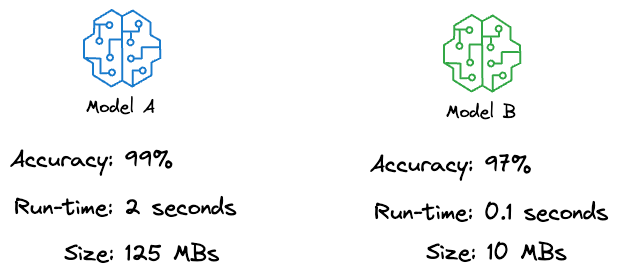

In [37]:
dense_bytes = 0 
for name , param in model.named_parameters():
    if "weight" in name: 
        dense_bytes += param.data.element_size() * param.data.nelement()
print(f"Model size: {dense_bytes/1024**2:.2f} MB") 


Model size: 0.90 MB


# VERY IMPORTANT NOTE: 

One important caveat here is that Pruning, by itself, does not reduce memory footprint or make inference faster, because the tensors remain the same size and most deep-learning libraries still use dense matrix multiplications.

To actually gain speed and memory improvements, you need to go further:

- Structured pruning + layer compaction: rebuild layers with fewer neurons/channels after pruning (e.g., fc2: 256→128 becomes 256→90, say).

- Sparse-aware kernels: run inference with libraries/hardware that skip zeros (e.g., cuSPARSE, NVIDIA Ampere 2:4 structured sparsity).

- Sparse storage techniques (e.g., CSR format) 

For instance, in our unstructured pruning demonstration, we can utilize the Compressed Sparse Row (CSR) format. It is a widely used format for sparse matrices because it effectively reduces memory usage:

In [38]:
import numpy as np
from scipy.sparse import csr_matrix

csr_bytes = 0
csr_weights = {}
for name, m in model.named_modules():
    if isinstance(m, nn.Linear):
        W = m.weight.detach().cpu().numpy()
        csr_W = csr_matrix(W)
        csr_weights[name] = csr_W
        csr_bytes += (csr_W.data.nbytes + csr_W.indices.nbytes + csr_W.indptr.nbytes)
print(f"CSR compressed size: {csr_bytes/1024/1024:.2f} MB")
print(f"Memory saving: {(1 - csr_bytes/dense_bytes)*100:.1f}%")

CSR compressed size: 0.36 MB
Memory saving: 59.8%


# lets SAVE the compressed model 


In [39]:
import pickle 
with open('model_mnist_pruned_csr.pkl', 'wb') as f:
    pickle.dump(csr_weights, f) 
print("Model saved as model_mnist_pruned_csr.pkl")  

Model saved as model_mnist_pruned_csr.pkl
